# Spin-Orbit Unmixing using jaxinv (Type 2)

last update: 5/8 (2025) Hajime Kawahara

In this tutorial, we use the Type 2 Bayesian linear inverse problem solver from jaxinv to estimate maps and spectra from multiband time-series data.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

Note: It is known that the current implementation does not work properly unless 64-bit mode is enabled.

In [2]:
from jax import config
config.update("jax_enable_x64", True)


In [3]:
import numpy as np
import healpy as hp
import matplotlib
from sot.core import sepmat
from sot.core.weight import compute_weight 



In [4]:
fontsize=16
matplotlib.rcParams.update({'font.size':fontsize})
np.random.seed(53)

#set geometry                                                               
inc=45.0/180.0*np.pi
Thetaeq=np.pi
zeta=23.4/180.0*np.pi
Pspin=23.9344699/24.0 #Pspin: a sidereal day                                
wspin=2*np.pi/Pspin
Porb=365.242190402
worb=2*np.pi/Porb                                                          \

Ni=256
obst=np.linspace(0.0,Porb,Ni)

{np.str_('ocean'): np.int64(0), np.str_('desert'): np.int64(100), np.str_('veg'): np.int64(30)}


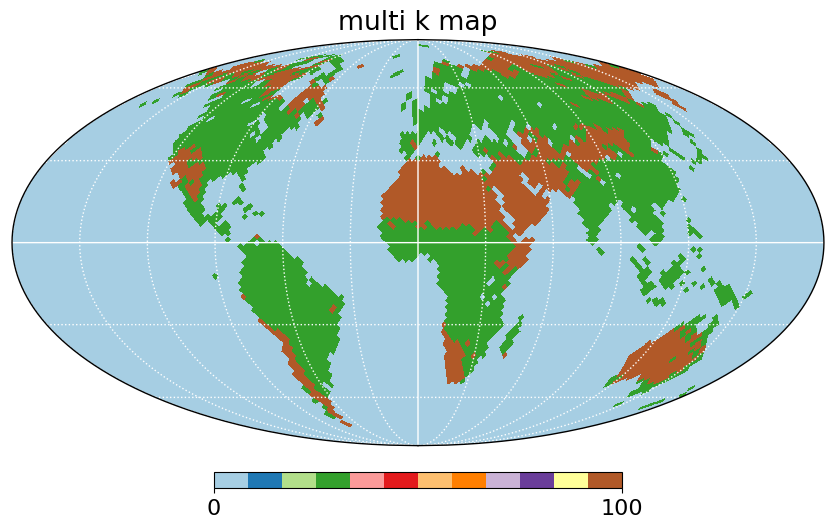

In [5]:
from sot.io.load_data import get_data_filepath
from sot.io.load_data import load_multi_kmap
import matplotlib.pyplot as plt

#multi k map
file_path = get_data_filepath("cmap3class.npz")
cmap, nclass, npix, nside, dict_class = load_multi_kmap(file_path)
Nk = len(dict_class)
print(dict_class)

hp.mollview(cmap, title="multi k map",flip="geo",cmap=plt.cm.Paired)
hp.graticule(color="white")


In [9]:
from sot.io.load_data import load_refdata

refdict = load_refdata()
reference_surfaces = {"ocean": "water", "desert": "soil", "veg": "vegetation"}
bands = [
    [0.4, 0.45],
    [0.45, 0.5],
    [0.5, 0.55],
    [0.55, 0.6],
    [0.6, 0.65],
    [0.65, 0.7],
    [0.7, 0.75],
    [0.75, 0.8],
    [0.8, 0.85],
    [0.85, 0.9],
]

from sot.core.toymap import generate_multiband_map
map_matrix, spectral_matrix = generate_multiband_map(
    cmap,
    dict_class,
    refdict,
    reference_surfaces,
    bands,
    onsky=True,
    sky=refdict["clear_sky"],
)

Nl = len(bands)
print(Nl)

10


In [ ]:
import jax.numpy as jnp
from jaxinv.model.linear import type2

# geometric weight
Thetav = worb * obst
Phiv = np.mod(wspin * obst, 2 * np.pi)
WI, WV = compute_weight(nside, zeta, inc, Thetaeq, Thetav, Phiv)
W = jnp.array(WV[:, :] * WI[:, :])
map_matrix = jnp.array(map_matrix)
spectral_matrix = jnp.array(spectral_matrix)

# Light curve
lc = type2(W, spectral_matrix, map_matrix)
noiselevel = 0.001
sigma = noiselevel * np.mean(lc)
noise = sigma * np.random.normal(0.0, 1.0, np.shape(lc))
lc = lc + noise

In [ ]:
import jax.numpy as jnp
from jaxinv.bayes.gpkernel import rbf
from jaxinv.bayes.meanmap import meanmap_inverse_type2

tau = 180.0
gamma = 10.0 / 180.0 * np.pi 
separation_matrix = sepmat.calc_sepmatrix(nside)
KS = rbf(separation_matrix, gamma)

#map k-direction covariance
KX = np.eye(Nk)

alpha = 0.25
Pid = jnp.eye(Ni*Nl) * sigma**-2 #when using jnp.eye Matrix becomes singular when x32
    
Mast = meanmap_inverse_type2(W, spectral_matrix, KS, KX, alpha, Pid, lc)


In [12]:
print(Mast.shape)

(12288, 3)


In [13]:
nside

32

In [101]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt

def rgb_mollweide(rgb_map, nside, xsize=1200, coord="G", red_scale=1.0, green_scale = 0.85, blue_scale = 0.6, nest=False):
    rgb_map = np.asarray(rgb_map)
    npix = hp.nside2npix(nside)
    assert rgb_map.shape == (npix, 3)

    rgb = np.nan_to_num(rgb_map, nan=0.0, posinf=0.0, neginf=0.0).astype(float)

    # robust normalize (per-channel)
    vmin = np.percentile(rgb, 1, axis=0)
    vmax = np.percentile(rgb, 99, axis=0)
    rgb = (rgb - vmin) / (vmax - vmin + 1e-30)
    rgb = np.clip(rgb, 0.0, 1.0)

    #red channel scaling
    rgb[:, 0] *= red_scale
    rgb[:, 0] = np.clip(rgb[:, 0], 0.0, 1.0)

    #green channel scaling
    rgb[:, 1] *= green_scale
    rgb[:, 1] = np.clip(rgb[:, 1], 0.0, 1.0)

    #blue channel scaling
    rgb[:, 2] *= blue_scale
    rgb[:, 2] = np.clip(rgb[:, 2], 0.0, 1.0)

    proj = hp.projector.MollweideProj(xsize=xsize, coord=coord)

    vec2pix = lambda x, y, z: hp.vec2pix(nside, x, y, z, nest=nest)

    # effective region mask 
    footprint = proj.projmap(np.ones(npix, dtype=float), vec2pix)
    valid = footprint > 0.5
    alpha = valid.astype(float)

    # 2) project RGB channels
    imgs = [proj.projmap(rgb[:, c], vec2pix) for c in range(3)]
    rgb_img = np.dstack(imgs)

    rgba = np.dstack([rgb_img, alpha])
    return rgba



In [102]:
def rgbmap_from_cmap(cmap):
    cmap = np.array(cmap)
    cmap_rgb = np.zeros([len(cmap), 3])
    vals = np.unique(cmap)
    if len(vals) != 3:
        raise ValueError("cmap must have exactly 3 unique values for RGB mapping.")
    for i in range(len(vals)):
        cmap_rgb[cmap == vals[i], i] = 1.0
    return cmap_rgb


cmap_rgb = rgbmap_from_cmap(cmap)
cmap_rgb_img = rgb_mollweide(
    np.vstack([cmap_rgb[:, 2], cmap_rgb[:, 1], cmap_rgb[:, 0]]).T, nside
)

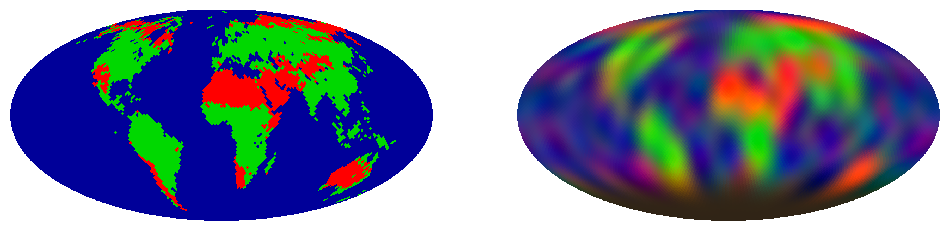

In [103]:
rgb_img = rgb_mollweide(np.vstack([Mast[:,1], Mast[:,2], Mast[:,0]]).T, nside)

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(1, 2, 2)
ax.imshow(rgb_img, origin="lower", interpolation="nearest")
ax.axis("off")
ax.invert_xaxis()
ax = fig.add_subplot(1, 2, 1)
ax.imshow(cmap_rgb_img, origin="lower", interpolation="nearest")
ax.axis("off")
ax.invert_xaxis()

plt.savefig("type2.png")
plt.show()
